<a href="https://colab.research.google.com/github/VarvaraSharutina/bioinfo/blob/main/bioinf_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Математические методы биоинформатики

### Home work 3. Предварительная обработка данных. PCA. Кластеризация

### Задание.

В файле *biomedical_data_raw.csv* представлены биомедицинские данные пациентов.

Для каждого пациента измерены следующие показатели:  
- Возраст (аge)  
- Пол (gender)      
- Индекс массы тела (bmi)  
- Систолическое артериальное давление (sbp)  
- Уровень холестерина (cholesterol)  
- Группа крови (blood_type)  
- Уровень образования (education_level)  
- Стадия заболевания (disease_stage)  
- Курение (smoking)  
- Основной симптом заболевания (main_symptom)  
- Тип лечения (treatment)  

Выполните следующие задания на основе представленного датасета:

1) Проведите полный цикл предварительной обработки данных: определение типа переменных, поиск дубликатов, обработка пропущенных значений, обработка категориальных признаков, анализ выбросов, нормализация. Разделение на обучающую и тестовую выборки не требуется. Сопроводите свой анализ необходимыми графиками (боксплоты, столбчатые диаграммы). Все действия должны быть объяснены.

2) Визуализируйте данные на плоскости применив метод главных компонент (PCA). На основе графика предположите, сколько кластеров существует в данных?

3) Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм кластеризации K-means. Число кластеров нужно выбрать так, чтобы по итогу между объектами из разных кластеров существовали статистически значимые отличия в значениях некоторых переменных. То есть на этом этапе необходимо также реализовать проверку статистических гипотез для сравнения переменных между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

4) Примените к исходным предобработанным данным (не PCA-трансформированным) функцию построения дендрограммы, используя разные методы оценки связи между кластерами. Какой метод позволяет получить более сбалансированные кластеры?

5) Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм агломеративной кластеризации с выбранным на предыдущем шаге методом оценки связи. Выберите оптимальное число кластеров на основе анализа дендрограммы и статистических различией между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

6) Сравните результаты K-means и агломеративной кластеризации. Насколько похожие кластеры были выделены этими алгоритмами?

7) Охарактеризуйте выделенные кластеры, определите их основные особенности (например, отличия по возрасту, полу и прочее).

In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

url = "https://raw.githubusercontent.com/VarvaraSharutina/bioinfo/main/biomedical_data_raw.csv"
data_raw = pd.read_csv(url)

In [235]:
data_raw

,patient_id,age,gender,bmi,sbp,cholesterol,blood_type,education_level,disease_stage,smoking,main_symptom,treatment
0,PAT_0001,37,М,22.5,103.0,4.17,A,NaN,I,нет,слабость,консервативное
1,PAT_0002,34,М,22.7,106.0,4.68,B,NaN,II,NaN,слабость,NaN
2,PAT_0003,38,Ж,20.6,116.0,3.71,A,1.0,II,нет,температура,NaN
3,PAT_0004,42,Ж,22.5,115.0,4.45,O,2.0,I,нет,одышка,консервативное
4,PAT_0005,94,М,22.6,110.0,3.93,A,NaN,I,да,слабость,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
607,PAT_0053,31,Ж,24.2,117.0,3.50,O,NaN,II,нет,слабость,NaN
608,PAT_0374,74,Ж,29.5,189.0,8.83,AB,0.0,IV,NaN,температура,хирургическое
609,PAT_0106,37,М,21.0,115.0,3.99,O,NaN,I,нет,слабость,NaN
610,PAT_0533,37,Ж,23.9,120.0,8.56,A,NaN,IV,да,боль,наблюдение


1. Предварительная обработка данных

- Возраст (аge) - дискретная
- Пол (gender) - бинарная   
- Индекс массы тела (bmi) - непрерывная
- Систолическое артериальное давление (sbp) - непрерывная
- Уровень холестерина (cholesterol) - непрерывная
- Группа крови (blood_type) - номинальная
- Уровень образования (education_level) - порядковая
- Стадия заболевания (disease_stage) - порядковая
- Курение (smoking) - бинарная
- Основной симптом заболевания (main_symptom) - номинальная
- Тип лечения (treatment) - номинальная

In [236]:
# Поиск неявных дубликатов
print(data_raw['gender'].unique())
print(data_raw['blood_type'].unique())
print(data_raw['education_level'].unique())
print(data_raw['smoking'].unique())
print(data_raw['treatment'].unique())
print(data_raw['disease_stage'].unique())
print(data_raw['main_symptom'].unique())

['М' 'Ж' 'м']
['A' 'B' 'O' 'AB']
[nan  1.  2.  0.]
['нет' nan 'да']
['консервативное' nan 'наблюдение' 'хирургическое' 'комбинированное']
['I' 'II' 'III' 'IV']
['слабость' 'температура' 'одышка' nan 'боль' 'кашель' 'кашель ' 'Боль']


In [237]:
data_raw['gender'] = data_raw['gender'].replace('м', 'М')
data_raw['main_symptom'] = data_raw['main_symptom'].replace('кашель ', 'кашель')
data_raw['main_symptom'] = data_raw['main_symptom'].replace('Боль', 'боль')

print(data_raw['gender'].unique())
print(data_raw['main_symptom'].unique())

['М' 'Ж']
['слабость' 'температура' 'одышка' nan 'боль' 'кашель']


In [238]:
# Поиск полных дубликатов
duplicates = data_raw.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates}")

# Удаление полных дубликатов
data_raw=data_raw.drop_duplicates(keep='first', inplace=False, ignore_index=False)

Количество полных дубликатов: 12


In [239]:
# Анализ пропусков
data_raw.isnull().sum()

,0
patient_id,0
age,0
gender,0
bmi,36
sbp,0
cholesterol,18
blood_type,0
education_level,468
disease_stage,0
smoking,24


In [240]:
#Удалим признаки, у которых больше 50% пропусков, в нашем случае это education_level и treatment
data_raw=data_raw.drop(labels=['education_level', 'treatment'], axis=1)

In [241]:
# Заполним пропуски в числовых признаках медианой
data_raw['bmi'] = data_raw['bmi'].fillna(data_raw['bmi'].median())
data_raw['cholesterol'] = data_raw['cholesterol'].fillna(data_raw['cholesterol'].median())

# Заполним пропуски в категориальных признаках наиболее часто встречающимся значением в этом столбце
data_raw['smoking'] = data_raw['smoking'].fillna(data_raw['smoking'].mode()[0])
data_raw['main_symptom'] = data_raw['main_symptom'].fillna(data_raw['main_symptom'].mode()[0])

In [242]:
data_raw.isnull().sum()

,0
patient_id,0
age,0
gender,0
bmi,0
sbp,0
cholesterol,0
blood_type,0
disease_stage,0
smoking,0
main_symptom,0


In [243]:
# Обработка категориальных признаков

# Бинарные признаки
data_raw['gender'] = data_raw['gender'].map({'М': 1,'Ж': 0})
data_raw['smoking'] = data_raw['smoking'].map({'да': 1,'нет': 0})

# Номинальные признаки
data_raw = pd.get_dummies(data_raw, columns=['blood_type']) # pd.get_dummies() - преобразования категориального признака в несколько бинарных столбцов
data_raw = pd.get_dummies(data_raw, columns=['main_symptom'])

# Порядковые признаки
data_raw['disease_stage'] = data_raw['disease_stage'].map({'I': 0, 'II': 1, 'III': 2, 'IV': 3})

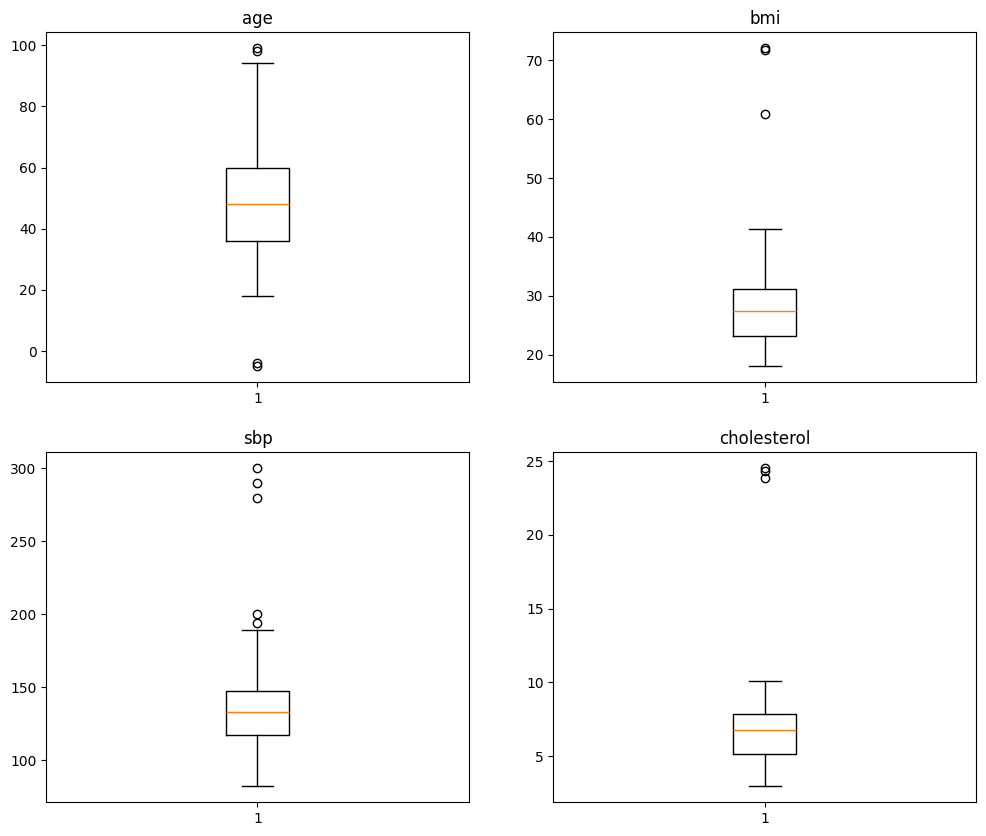


age
Границы: [0.00, 96.00]
Количество выбросов: 4 
Минимальное значение выброса: -5
Максимальное значение выброса: 99
Bыбросы: [-5, -4, 99, 98]

bmi
Границы: [11.20, 43.20]
Количество выбросов: 3 
Минимальное значение выброса: 60.97133306118592
Максимальное значение выброса: 72.07453435070262
Bыбросы: [72.07453435070262, 60.97133306118592, 71.68536404129001]

sbp
Границы: [72.00, 192.00]
Количество выбросов: 5 
Минимальное значение выброса: 194.0
Максимальное значение выброса: 299.85109022808484
Bыбросы: [279.2495874350959, 299.85109022808484, 290.0205431246839, 194.0, 200.0]

cholesterol
Границы: [1.03, 11.99]
Количество выбросов: 3 
Минимальное значение выброса: 23.841941849259776
Максимальное значение выброса: 24.513367251540974
Bыбросы: [23.841941849259776, 24.323338998786653, 24.513367251540974]


In [244]:
# Для анализа выбросов построим ящики с усами
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# age
axes[0, 0].boxplot(data_raw['age'])
axes[0, 0].set_title('age')

# bmi
axes[0, 1].boxplot(data_raw['bmi'])
axes[0, 1].set_title('bmi')

# sbp
axes[1, 0].boxplot(data_raw['sbp'])
axes[1, 0].set_title('sbp')

# cholesterol
axes[1, 1].boxplot(data_raw['cholesterol'])
axes[1, 1].set_title('cholesterol')

plt.show()


def analysis_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    mini = Q1 - 1.5 * IQR
    maxi = Q3 + 1.5 * IQR
    outliers = data[(data[column] < mini) | (data[column] > maxi)]
    return outliers, mini, maxi

numeric_cols = ['age', 'bmi', 'sbp', 'cholesterol']

for col in numeric_cols:
    outliers, min, max = analysis_outliers(data_raw, col)
    print(f"\n{col}")
    print(f"Границы: [{min:.2f}, {max:.2f}]")
    print(f"Количество выбросов: {len(outliers)} ")
    if len(outliers) > 0:
        print(f"Минимальное значение выброса: {outliers[col].min()}")
        print(f"Максимальное значение выброса: {outliers[col].max()}")
        print(f"Bыбросы: {outliers[col].tolist()}")

In [245]:
# Удалим образды, которые являются выбросами
for col in numeric_cols:
    outliers, min, max = analysis_outliers(data_raw, col)
    data_raw = data_raw[~data_raw.index.isin(outliers.index)]
    df=data_raw[~data_raw.index.isin(outliers.index)]

In [246]:
# z-нормализация
scaler = StandardScaler()
data_raw[numeric_cols] = scaler.fit_transform(data_raw[numeric_cols])

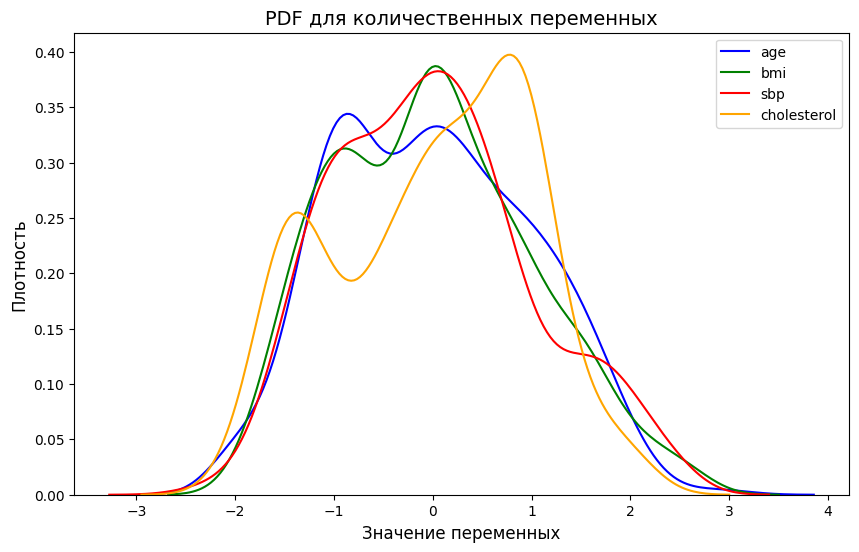

In [247]:
colors = ['blue', 'green', 'red', 'orange']

plt.figure(figsize=(10, 6))

for i, var in enumerate(numeric_cols):
  data = data_raw[var]
  sns.kdeplot(data, label=var, color=colors[i])

plt.title('PDF для количественных переменных', fontsize=14)
plt.xlabel('Значение переменных', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.show()

2. Визуализируйте данные на плоскости применив метод главных компонент (PCA). На основе графика предположите, сколько кластеров существует в данных?

На основе графика можно предположить, что существует 2 или 4 кластера

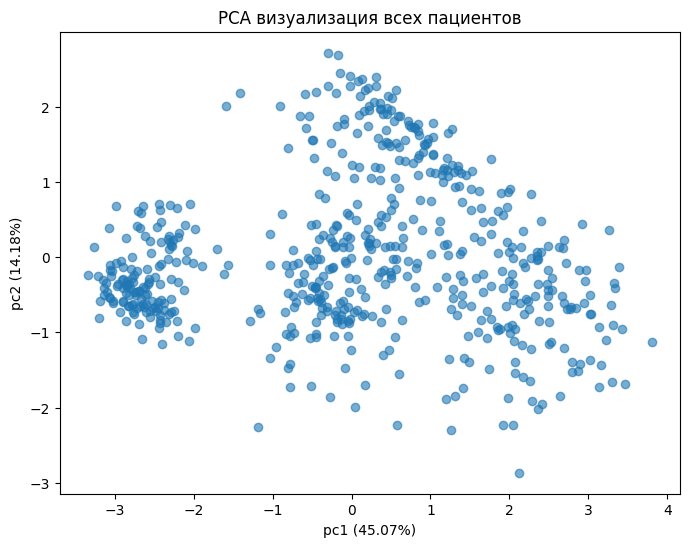

In [248]:
cols = [col for col in data_raw.columns if col not in ['patient_id']]
X = data_raw[cols].values

# Применяем PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
plt.xlabel(f'pc1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'pc2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('PCA визуализация всех пациентов')
plt.show()



3. Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм кластеризации K-means. Число кластеров нужно выбрать так, чтобы по итогу между объектами из разных кластеров существовали статистически значимые отличия в значениях некоторых переменных. То есть на этом этапе необходимо также реализовать проверку статистических гипотез для сравнения переменных между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

In [249]:
X_kmeans = data_raw[cols].values
results = {}
K_range = range(2, 9)

for k in K_range:
    print(f"\nАнализ для k={k}")

    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_kmeans)
    centroids = kmeans.cluster_centers_

    significant_features = []
    feature_names = cols

    for i, feature in enumerate(feature_names):
        groups = [X_kmeans[cluster_labels == cluster, i] for cluster in range(k)]
        stat, p_value = stats.f_oneway(*groups)
        if p_value < 0.05:
                significant_features.append({
                    'feature': feature,
                    'p_value': p_value,
                    'stat': stat
                })
    results[k] = significant_features

    print(f"Найдено статистически значимых признаков (p < 0.05): {len(significant_features)} из {len(feature_names)}")
    if significant_features:
      print('Топ 5 этих признаков:')
      sorted_features = sorted(significant_features, key=lambda x: x['p_value'])[:5]
      for feat in sorted_features:
          print(f"  {feat['feature']}: p={feat['p_value']:.4f}, statistics={feat['stat']:.2f}")


Анализ для k=2
Найдено статистически значимых признаков (p < 0.05): 12 из 16
Топ 5 этих признаков:
  cholesterol: p=0.0000, statistics=795.17
  disease_stage: p=0.0000, statistics=714.35
  sbp: p=0.0000, statistics=366.14
  bmi: p=0.0000, statistics=284.26
  age: p=0.0000, statistics=225.94

Анализ для k=3
Найдено статистически значимых признаков (p < 0.05): 14 из 16
Топ 5 этих признаков:
  sbp: p=0.0000, statistics=603.81
  cholesterol: p=0.0000, statistics=544.69
  age: p=0.0000, statistics=408.35
  bmi: p=0.0000, statistics=373.05
  disease_stage: p=0.0000, statistics=307.68

Анализ для k=4
Найдено статистически значимых признаков (p < 0.05): 14 из 16
Топ 5 этих признаков:
  cholesterol: p=0.0000, statistics=733.38
  disease_stage: p=0.0000, statistics=440.58
  sbp: p=0.0000, statistics=416.61
  age: p=0.0000, statistics=343.63
  bmi: p=0.0000, statistics=290.74

Анализ для k=5
Найдено статистически значимых признаков (p < 0.05): 15 из 16
Топ 5 этих признаков:
  cholesterol: p=0.00

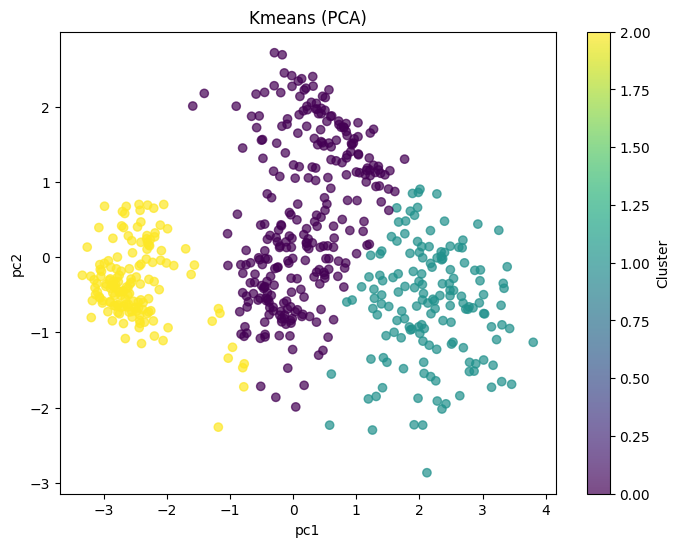

In [250]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
km_cluster_labels = kmeans.fit_predict(X_kmeans)

pca = PCA(n_components=2)
X_pca_kmeans = pca.fit_transform(X_kmeans)
data_raw['cluster_km'] = km_cluster_labels

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_kmeans[:,0], X_pca_kmeans[:,1], c=data_raw['cluster_km'], cmap='viridis',alpha=0.7)
plt.xlabel(f'pc1')
plt.ylabel(f'pc2')
plt.title('Kmeans (PCA)')
plt.colorbar(label='Cluster')
plt.show()

4. Примените к исходным предобработанным данным (не PCA-трансформированным) функцию построения дендрограммы, используя разные методы оценки связи между кластерами. Какой метод позволяет получить более сбалансированные кластеры?

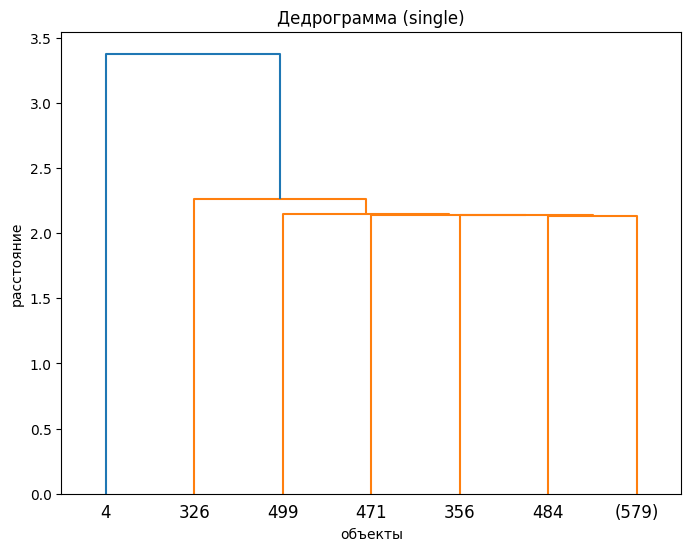

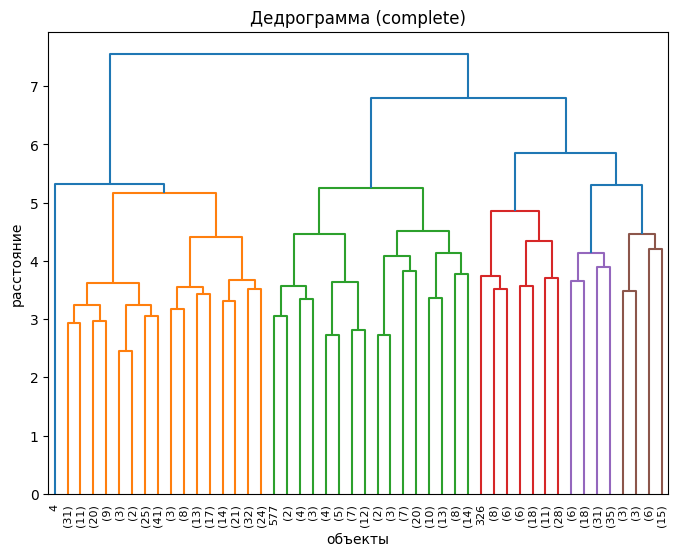

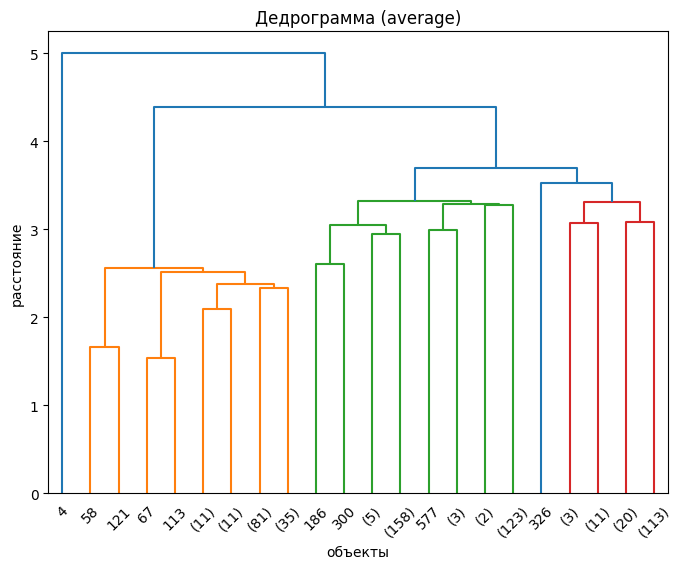

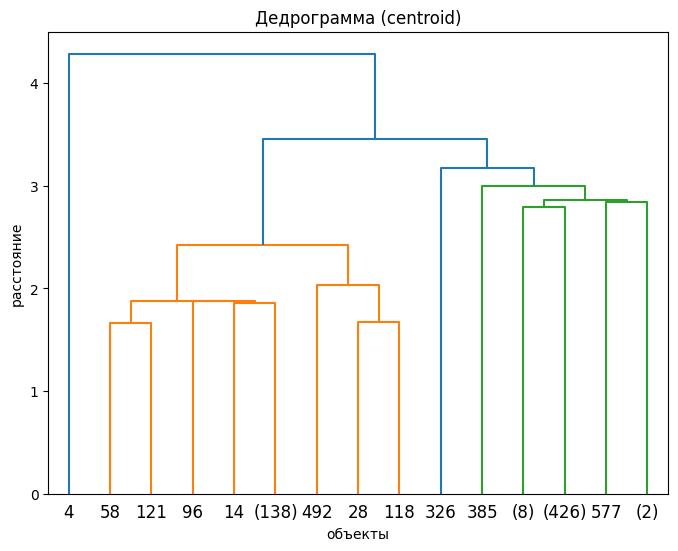

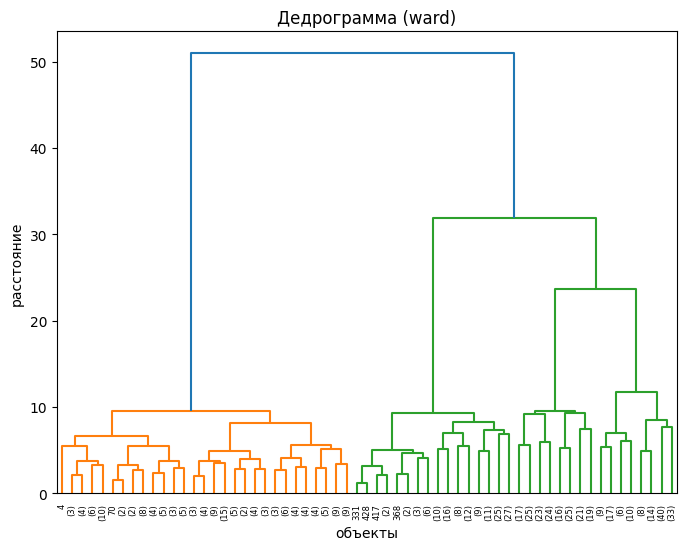

In [251]:
X = data_raw[cols].values
methods = ['single', 'complete', 'average', 'centroid', 'ward']

for i, method in enumerate(methods):
    plt.figure(figsize=(8,6))

    Z = linkage(X, method=method)

    dendrogram(Z, truncate_mode='level', p=5)

    plt.title(f'Дедрограмма ({method})')
    plt.xlabel('объекты')
    plt.ylabel('расстояние')
    plt.show()

 Метод ward позволяет получить более сбалансированные кластеры (группы имеют примерно одинаковый размер, дерево разветвляется равномерно, нет одной огромной ветки и маленьких веток)

5. Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм агломеративной кластеризации с выбранным на предыдущем шаге методом оценки связи. Выберите оптимальное число кластеров на основе анализа дендрограммы и статистических различией между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

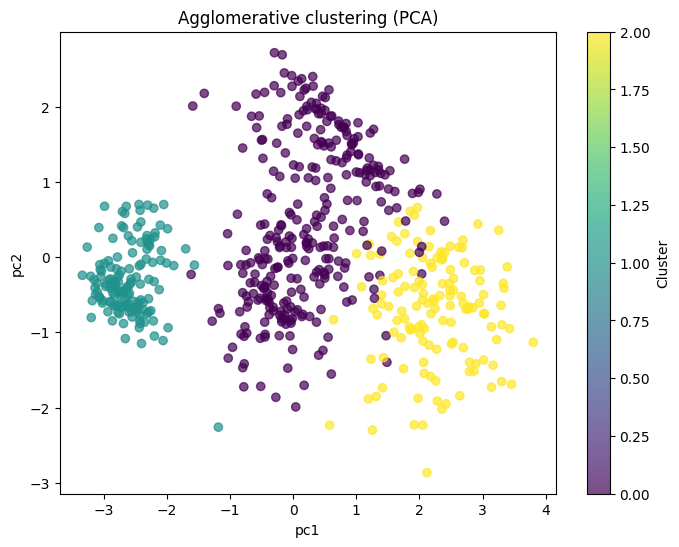

In [252]:
X_agg = data_raw[cols].values
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_cluster_labels = agg.fit_predict(X_agg)

pca = PCA(n_components=2)
X_pca_agg = pca.fit_transform(X_agg)
data_raw['cluster_agg'] = agg_cluster_labels

plt.figure(figsize=(8,6))
plt.scatter(X_pca_agg[:,0], X_pca_agg[:,1], c=data_raw['cluster_agg'], cmap='viridis', alpha=0.7)
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("Agglomerative clustering (PCA)")
plt.colorbar(label='Cluster')
plt.show()

6. Сравните результаты K-means и агломеративной кластеризации. Насколько похожие кластеры были выделены этими алгоритмами?

Если брать одно и то же число кластеров, то K-means и агломеративная кластеризация выдают достаточно схожие результатыми, с небольшим количеством отклонений друг от друга. Но можно заметить, что при агломеративной кластеризации наслаивание объктов одно кластера на другой более явно в некоторых областях, при K-means же сильных пересечний мы не наблюдаем.

In [253]:
cluster_table = pd.DataFrame({'Agglomerative': data_raw['cluster_agg'].value_counts().sort_index(), 'KMeans': data_raw['cluster_km'].value_counts().sort_index()})
print(cluster_table)

   Agglomerative  KMeans
0            307     281
1            143     152
2            135     152


7. Охарактеризуйте выделенные кластеры, определите их основные особенности (например, отличия по возрасту, полу и прочее).

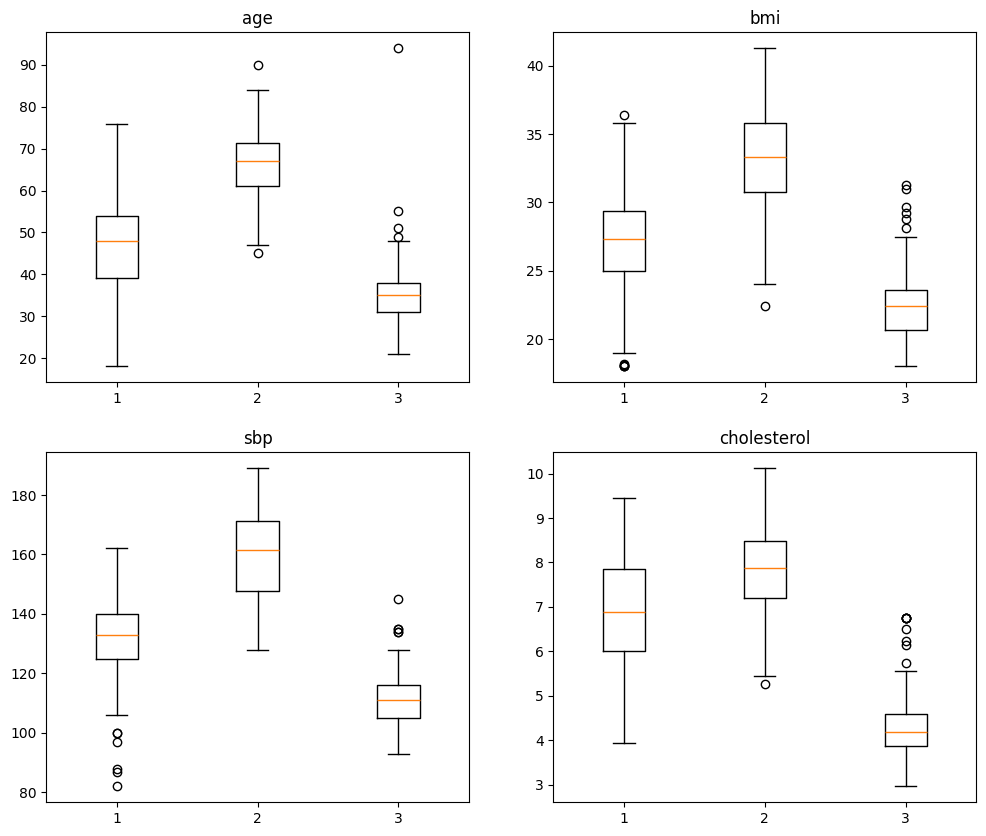

In [254]:
df['cluster_km'] = km_cluster_labels
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# age
axes[0, 0].boxplot([df[df['cluster_km']==0]['age'], df[df['cluster_km']==1]['age'], df[df['cluster_km']==2]['age']])
axes[0, 0].set_title('age')

# bmi
axes[0, 1].boxplot([df[df['cluster_km']==0]['bmi'], df[df['cluster_km']==1]['bmi'], df[df['cluster_km']==2]['bmi']])
axes[0, 1].set_title('bmi')

# sbp
axes[1, 0].boxplot([df[df['cluster_km']==0]['sbp'], df[df['cluster_km']==1]['sbp'], df[df['cluster_km']==2]['sbp']])
axes[1, 0].set_title('sbp')

# cholesterol
axes[1, 1].boxplot([df[df['cluster_km']==0]['cholesterol'], df[df['cluster_km']==1]['cholesterol'], df[df['cluster_km']==2]['cholesterol']])
axes[1, 1].set_title('cholesterol')

plt.show()

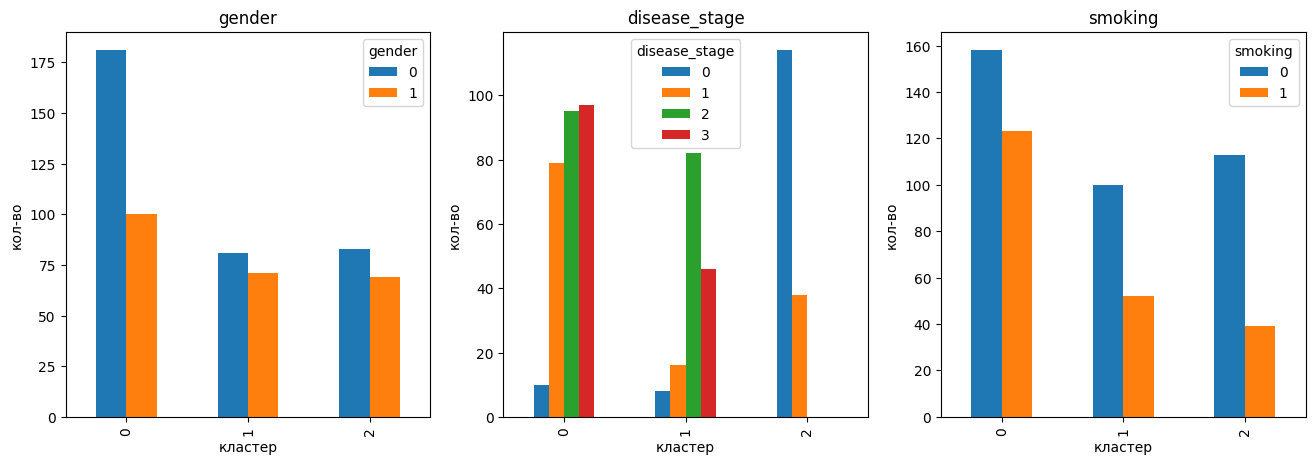

In [255]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# gender {'М': 1,'Ж': 0}
gender_table = pd.crosstab(df['cluster_km'], df['gender'])
gender_table.plot(kind='bar', ax=axes[0])
axes[0].set_title('gender')
axes[0].set_xlabel('кластер')
axes[0].set_ylabel('кол-во')

# disease_stage ({'I': 0, 'II': 1, 'III': 2, 'IV': 3})
disease_table = pd.crosstab(df['cluster_km'], df['disease_stage'])
disease_table.plot(kind='bar', ax=axes[1])
axes[1].set_title('disease_stage')
axes[1].set_xlabel('кластер')
axes[1].set_ylabel('кол-во')

# smoking ({'да': 1,'нет': 0})
smoking_table = pd.crosstab(df['cluster_km'], df['smoking'])
smoking_table.plot(kind='bar', ax=axes[2])
axes[2].set_title('smoking')
axes[2].set_xlabel('кластер')
axes[2].set_ylabel('кол-во')

plt.show()